# A/B Testing Synthetic - MyFinance

Notebook ini mendemonstrasikan A/B Testing menggunakan data sintetis untuk membandingkan dua flow input transaksi:

- **Variant A:** user melakukan input kategori secara manual.
- **Variant B:** user dibantu fitur AI auto-categorization.

> Catatan penting: dataset ini adalah data sintetis/simulasi, bukan hasil eksperimen pengguna nyata.


## 1. Setup Library

Library yang digunakan:
- `numpy` dan `pandas` untuk membuat dan mengolah data sintetis.
- `scipy.stats` untuk uji statistik.
- `matplotlib` untuk visualisasi sederhana.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

RANDOM_SEED = 42
N_USERS_PER_GROUP = 60
OUTPUT_DIR = Path("ab_testing_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Membuat Synthetic Dataset

Synthetic dataset dibuat untuk mensimulasikan hasil eksperimen A/B Testing. Variant B diasumsikan memiliki pengalaman yang lebih baik karena user dibantu auto-categorization.

Metrik yang digunakan:

| Metric | Interpretasi |
|---|---|
| `completion_time_sec` | Waktu menyelesaikan input transaksi. Lebih rendah lebih baik. |
| `transaction_saved` | Apakah transaksi berhasil disimpan. Lebih tinggi lebih baik. |
| `category_correct` | Apakah kategori transaksi benar. Lebih tinggi lebih baik. |
| `num_corrections` | Jumlah koreksi yang dilakukan user. Lebih rendah lebih baik. |
| `satisfaction_score` | Skor kepuasan user 1-5. Lebih tinggi lebih baik. |


In [2]:
def generate_synthetic_ab_data(n_users_per_group: int = N_USERS_PER_GROUP, seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    total_rows = n_users_per_group * 2
    user_ids = [f"U{i:03d}" for i in range(1, total_rows + 1)]
    variants = np.array(["A"] * n_users_per_group + ["B"] * n_users_per_group)

    completion_time_A = np.clip(rng.normal(loc=95, scale=18, size=n_users_per_group), 45, 160)
    completion_time_B = np.clip(rng.normal(loc=58, scale=14, size=n_users_per_group), 25, 120)
    completion_time_sec = np.concatenate([completion_time_A, completion_time_B]).round(2)

    category_correct_A = rng.binomial(n=1, p=0.72, size=n_users_per_group)
    category_correct_B = rng.binomial(n=1, p=0.88, size=n_users_per_group)
    category_correct = np.concatenate([category_correct_A, category_correct_B])

    corrections_A = np.clip(rng.poisson(lam=1.7, size=n_users_per_group), 0, 6)
    corrections_B = np.clip(rng.poisson(lam=0.7, size=n_users_per_group), 0, 4)
    num_corrections = np.concatenate([corrections_A, corrections_B])

    satisfaction_A = np.clip(np.rint(rng.normal(loc=3.2, scale=0.8, size=n_users_per_group)), 1, 5).astype(int)
    satisfaction_B = np.clip(np.rint(rng.normal(loc=4.1, scale=0.7, size=n_users_per_group)), 1, 5).astype(int)
    satisfaction_score = np.concatenate([satisfaction_A, satisfaction_B])

    transaction_saved_A = rng.binomial(n=1, p=0.90, size=n_users_per_group)
    transaction_saved_B = rng.binomial(n=1, p=0.97, size=n_users_per_group)
    transaction_saved = np.concatenate([transaction_saved_A, transaction_saved_B])

    df = pd.DataFrame({
        "user_id": user_ids,
        "variant": variants,
        "completion_time_sec": completion_time_sec,
        "transaction_saved": transaction_saved,
        "category_correct": category_correct,
        "num_corrections": num_corrections,
        "satisfaction_score": satisfaction_score,
    })

    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

df = generate_synthetic_ab_data()
df.to_csv(OUTPUT_DIR / "synthetic_ab_testing_data.csv", index=False)
df.head()


,user_id,variant,completion_time_sec,transaction_saved,category_correct,num_corrections,satisfaction_score
0,U045,A,97.10,1,0,2,4
1,U048,A,99.02,0,0,0,3
2,U005,A,59.88,1,1,1,3
3,U056,A,83.50,1,0,4,4
4,U027,A,104.58,1,1,3,5


## 3. Summary Metric per Variant

Tahap ini menghitung rata-rata dan proporsi metrik utama untuk Variant A dan Variant B.


In [3]:
def summarize_by_variant(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby("variant")
        .agg(
            users=("user_id", "count"),
            avg_completion_time_sec=("completion_time_sec", "mean"),
            median_completion_time_sec=("completion_time_sec", "median"),
            completion_rate=("transaction_saved", "mean"),
            category_accuracy=("category_correct", "mean"),
            avg_num_corrections=("num_corrections", "mean"),
            avg_satisfaction_score=("satisfaction_score", "mean"),
        )
        .reset_index()
    )

    summary["completion_rate"] = summary["completion_rate"] * 100
    summary["category_accuracy"] = summary["category_accuracy"] * 100

    return summary

summary = summarize_by_variant(df)
summary.to_csv(OUTPUT_DIR / "ab_testing_summary_by_variant.csv", index=False)
summary


,variant,users,avg_completion_time_sec,median_completion_time_sec,completion_rate,category_accuracy,avg_num_corrections,avg_satisfaction_score
0,A,60,96.175333,97.200,93.333333,70.000000,1.583333,3.200000
1,B,60,55.395000,54.885,98.333333,88.333333,0.683333,3.916667


## 4. Lift Analysis

Lift analysis digunakan untuk melihat perubahan nilai Variant B dibandingkan Variant A. Untuk metrik seperti waktu dan jumlah koreksi, nilai yang lebih rendah berarti lebih baik. Untuk completion rate, akurasi, dan satisfaction score, nilai yang lebih tinggi berarti lebih baik.


In [4]:
def calculate_lift(summary: pd.DataFrame) -> pd.DataFrame:
    a = summary[summary["variant"] == "A"].iloc[0]
    b = summary[summary["variant"] == "B"].iloc[0]

    return pd.DataFrame([
        {
            "metric": "Completion time",
            "variant_A": a["avg_completion_time_sec"],
            "variant_B": b["avg_completion_time_sec"],
            "difference_B_minus_A": b["avg_completion_time_sec"] - a["avg_completion_time_sec"],
            "interpretation": "Lower is better",
        },
        {
            "metric": "Completion rate",
            "variant_A": a["completion_rate"],
            "variant_B": b["completion_rate"],
            "difference_B_minus_A": b["completion_rate"] - a["completion_rate"],
            "interpretation": "Higher is better",
        },
        {
            "metric": "Category accuracy",
            "variant_A": a["category_accuracy"],
            "variant_B": b["category_accuracy"],
            "difference_B_minus_A": b["category_accuracy"] - a["category_accuracy"],
            "interpretation": "Higher is better",
        },
        {
            "metric": "Number of corrections",
            "variant_A": a["avg_num_corrections"],
            "variant_B": b["avg_num_corrections"],
            "difference_B_minus_A": b["avg_num_corrections"] - a["avg_num_corrections"],
            "interpretation": "Lower is better",
        },
        {
            "metric": "Satisfaction score",
            "variant_A": a["avg_satisfaction_score"],
            "variant_B": b["avg_satisfaction_score"],
            "difference_B_minus_A": b["avg_satisfaction_score"] - a["avg_satisfaction_score"],
            "interpretation": "Higher is better",
        },
    ])

lift = calculate_lift(summary)
lift.to_csv(OUTPUT_DIR / "ab_testing_lift_analysis.csv", index=False)
lift


,metric,variant_A,variant_B,difference_B_minus_A,interpretation
0,Completion time,96.175333,55.395000,-40.780333,Lower is better
1,Completion rate,93.333333,98.333333,5.000000,Higher is better
2,Category accuracy,70.000000,88.333333,18.333333,Higher is better
3,Number of corrections,1.583333,0.683333,-0.900000,Lower is better
4,Satisfaction score,3.200000,3.916667,0.716667,Higher is better


## 5. Statistical Testing

Uji statistik digunakan untuk mengecek apakah perbedaan antar variant cukup signifikan secara statistik.

- `completion_time_sec`, `num_corrections`, dan `satisfaction_score`: Welch's t-test.
- `transaction_saved` dan `category_correct`: Chi-square test.

Karena data ini sintetis, hasil uji statistik digunakan sebagai demonstrasi metode, bukan validasi final terhadap pengguna nyata.


In [5]:
def run_statistical_tests(df: pd.DataFrame) -> pd.DataFrame:
    results = []

    group_a = df[df["variant"] == "A"]
    group_b = df[df["variant"] == "B"]

    for metric in ["completion_time_sec", "num_corrections", "satisfaction_score"]:
        if SCIPY_AVAILABLE:
            test_stat, p_value = stats.ttest_ind(group_a[metric], group_b[metric], equal_var=False)
            test_name = "Welch t-test"
        else:
            test_stat, p_value = np.nan, np.nan
            test_name = "Not available: install scipy"

        results.append({
            "metric": metric,
            "test": test_name,
            "statistic": test_stat,
            "p_value": p_value,
            "significant_at_0.05": bool(p_value < 0.05) if not np.isnan(p_value) else None,
        })

    for metric in ["transaction_saved", "category_correct"]:
        contingency = pd.crosstab(df["variant"], df[metric])

        if SCIPY_AVAILABLE:
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
            test_name = "Chi-square test"
            test_stat = chi2
        else:
            test_stat, p_value = np.nan, np.nan
            test_name = "Not available: install scipy"

        results.append({
            "metric": metric,
            "test": test_name,
            "statistic": test_stat,
            "p_value": p_value,
            "significant_at_0.05": bool(p_value < 0.05) if not np.isnan(p_value) else None,
        })

    return pd.DataFrame(results)

tests = run_statistical_tests(df)
tests.to_csv(OUTPUT_DIR / "ab_testing_statistical_tests.csv", index=False)
tests


,metric,test,statistic,p_value,significant_at_0.05
0,completion_time_sec,Welch t-test,17.762730,3.926872e-34,True
1,num_corrections,Welch t-test,4.408085,2.755957e-05,True
2,satisfaction_score,Welch t-test,-4.950689,2.569996e-06,True
3,transaction_saved,Chi-square test,0.834783,3.608932e-01,False
4,category_correct,Chi-square test,5.052632,2.458857e-02,True


## 6. Visualisasi Perbandingan

Visualisasi berikut membantu memperlihatkan perbedaan metric utama antara Variant A dan Variant B.


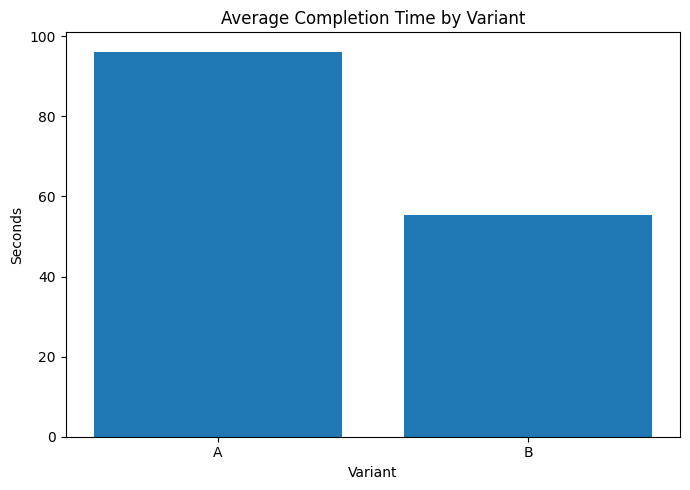

In [6]:
def plot_metric_bar(summary: pd.DataFrame, metric: str, title: str, ylabel: str, output_file: Path) -> None:
    plt.figure(figsize=(7, 5))
    plt.bar(summary["variant"], summary[metric])
    plt.title(title)
    plt.xlabel("Variant")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(output_file, dpi=150)
    plt.show()

plot_metric_bar(
    summary,
    metric="avg_completion_time_sec",
    title="Average Completion Time by Variant",
    ylabel="Seconds",
    output_file=OUTPUT_DIR / "chart_avg_completion_time.png",
)


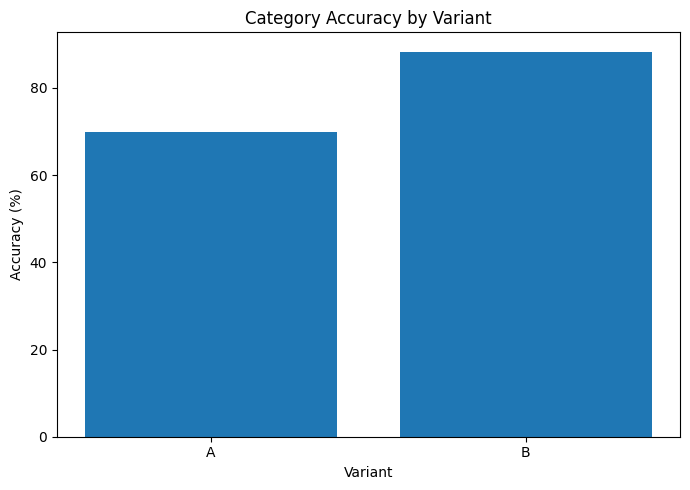

In [7]:
plot_metric_bar(
    summary,
    metric="category_accuracy",
    title="Category Accuracy by Variant",
    ylabel="Accuracy (%)",
    output_file=OUTPUT_DIR / "chart_category_accuracy.png",
)


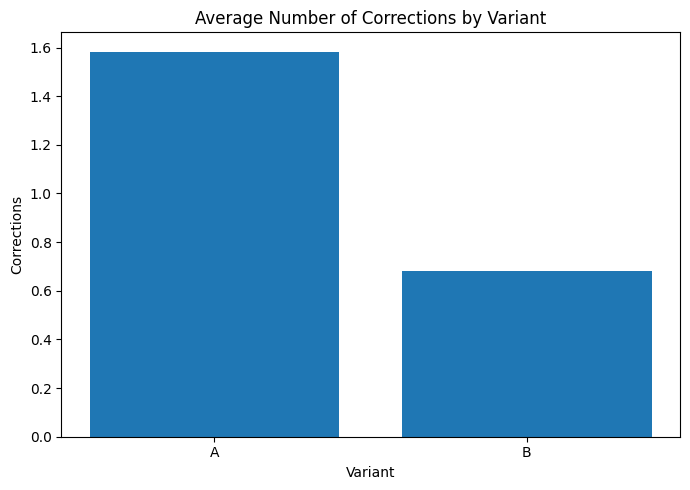

In [8]:
plot_metric_bar(
    summary,
    metric="avg_num_corrections",
    title="Average Number of Corrections by Variant",
    ylabel="Corrections",
    output_file=OUTPUT_DIR / "chart_avg_num_corrections.png",
)


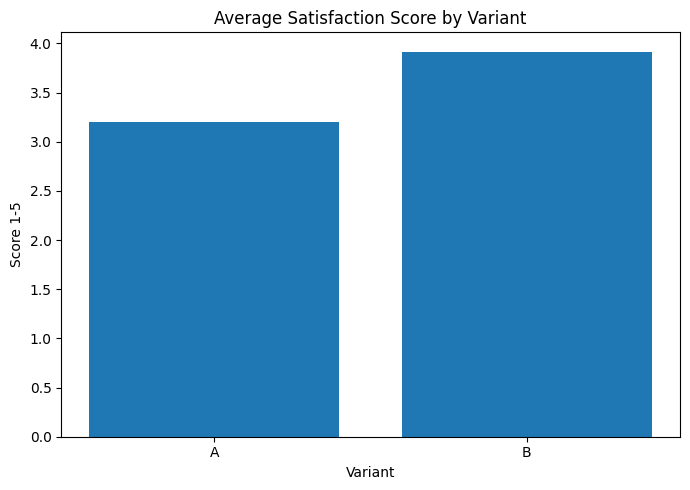

In [9]:
plot_metric_bar(
    summary,
    metric="avg_satisfaction_score",
    title="Average Satisfaction Score by Variant",
    ylabel="Score 1-5",
    output_file=OUTPUT_DIR / "chart_avg_satisfaction_score.png",
)


## 7. Decision Rule

Decision rule sederhana:
- Variant B dipilih jika lebih cepat,
- lebih akurat,
- membutuhkan koreksi lebih sedikit,
- satisfaction lebih tinggi,
- dan minimal dua metrik utama signifikan secara statistik.


In [10]:
def make_decision(summary: pd.DataFrame, tests: pd.DataFrame) -> str:
    a = summary[summary["variant"] == "A"].iloc[0]
    b = summary[summary["variant"] == "B"].iloc[0]

    faster = b["avg_completion_time_sec"] < a["avg_completion_time_sec"]
    more_accurate = b["category_accuracy"] > a["category_accuracy"]
    fewer_corrections = b["avg_num_corrections"] < a["avg_num_corrections"]
    more_satisfied = b["avg_satisfaction_score"] > a["avg_satisfaction_score"]

    key_metrics = ["completion_time_sec", "category_correct", "num_corrections", "satisfaction_score"]
    significant_count = tests[
        tests["metric"].isin(key_metrics) & (tests["significant_at_0.05"] == True)
    ].shape[0]

    if faster and more_accurate and fewer_corrections and more_satisfied and significant_count >= 2:
        return (
            "Rekomendasi: Variant B layak dipilih untuk flow utama karena secara simulasi "
            "lebih cepat, lebih akurat, membutuhkan koreksi lebih sedikit, dan memiliki "
            "satisfaction score lebih tinggi."
        )

    return (
        "Rekomendasi: Hasil belum cukup kuat untuk memilih Variant B secara penuh. "
        "Lakukan eksperimen dengan data pengguna nyata atau tambah jumlah sampel."
    )

decision = make_decision(summary, tests)
decision


'Rekomendasi: Variant B layak dipilih untuk flow utama karena secara simulasi lebih cepat, lebih akurat, membutuhkan koreksi lebih sedikit, dan memiliki satisfaction score lebih tinggi.'

## 8. Export Report

Hasil analisis diekspor menjadi file markdown agar mudah dimasukkan ke laporan teknis atau dokumentasi repository.


In [11]:
report = f'''# A/B Testing Synthetic Report - MyFinance

## Context

A/B Testing ini menggunakan data sintetis untuk membandingkan dua flow input transaksi:

- Variant A: input kategori manual
- Variant B: input transaksi dengan bantuan AI auto-categorization

Catatan: Data ini adalah simulasi dan bukan data eksperimen pengguna nyata.

## Summary by Variant

{summary.to_markdown(index=False)}

## Lift Analysis

{lift.to_markdown(index=False)}

## Statistical Tests

{tests.to_markdown(index=False)}

## Decision

{decision}

## Interpretation

Jika hasil ini digunakan dalam laporan teknis, tuliskan bahwa eksperimen ini merupakan simulasi untuk mendemonstrasikan metode evaluasi. Untuk validasi final, eksperimen perlu diulang menggunakan data pengguna nyata.
'''

(OUTPUT_DIR / "ab_testing_report.md").write_text(report, encoding="utf-8")
print(report)


# A/B Testing Synthetic Report - MyFinance

## Context

A/B Testing ini menggunakan data sintetis untuk membandingkan dua flow input transaksi:

- Variant A: input kategori manual
- Variant B: input transaksi dengan bantuan AI auto-categorization

Catatan: Data ini adalah simulasi dan bukan data eksperimen pengguna nyata.

## Summary by Variant

| variant   |   users |   avg_completion_time_sec |   median_completion_time_sec |   completion_rate |   category_accuracy |   avg_num_corrections |   avg_satisfaction_score |
|:----------|--------:|--------------------------:|-----------------------------:|------------------:|--------------------:|----------------------:|-------------------------:|
| A         |      60 |                   96.1753 |                       97.2   |           93.3333 |             70      |              1.58333  |                  3.2     |
| B         |      60 |                   55.395  |                       54.885 |           98.3333 |             88.3333 |

## 9. Kesimpulan

Berdasarkan synthetic A/B Testing, Variant B atau flow berbantuan AI auto-categorization dapat dievaluasi sebagai kandidat flow utama karena diharapkan dapat mempercepat input transaksi, meningkatkan akurasi kategori, mengurangi koreksi manual, dan meningkatkan kepuasan user.

Namun, karena dataset yang digunakan adalah simulasi, hasil ini harus ditulis sebagai **demonstrasi metode evaluasi**, bukan bukti final dari eksperimen pengguna nyata.
